# 01. Data Exploration
Exploring the TML-Database ATP match dataset (2000-2026).

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('imports ok')

imports ok


In [2]:
df = pd.read_parquet('../data/processed/matches_clean.parquet')

print(f'Shape: {df.shape}')
print(f'Date range: {df["tourney_date"].min().date()} → {df["tourney_date"].max().date()}')
print(f'\nDtypes:\n{df.dtypes}')
df.sample(5, random_state=42)

Shape: (74848, 67)
Date range: 2000-01-03 → 2026-01-17

Dtypes:
tourney_id           str
tourney_name         str
surface              str
draw_size        float64
tourney_level        str
                  ...   
l_ace_rate       float64
l_df_rate        float64
w_return_pct     float64
l_return_pct     float64
n_sets             int64
Length: 67, dtype: object


,tourney_id,tourney_name,surface,draw_size,tourney_level,indoor,tourney_date,match_num,winner_id,winner_seed,...,l_serve_pct,l_1st_in_pct,l_1st_won_pct,l_2nd_won_pct,l_bp_saved_pct,l_ace_rate,l_df_rate,w_return_pct,l_return_pct,n_sets
13535,2004-403,Miami Masters,Hard,96.0,M,O,2004-03-22,5.0,P280,NaN,...,0.532468,0.480519,0.594595,0.475000,0.555556,0.300000,0.400000,0.467532,0.363636,2
31463,2010-580,Australian Open,Hard,128.0,G,O,2010-01-18,41.0,C977,14.0,...,0.592593,0.601852,0.661538,0.488372,0.705882,0.000000,0.062500,0.407407,0.304348,3
18107,2005-475,Sopot,Clay,32.0,250,O,2005-08-01,24.0,MC65,NaN,...,0.555556,0.666667,0.583333,0.500000,0.555556,0.181818,0.090909,0.444444,0.381579,2
67458,2023-410,Monte Carlo Masters,Clay,64.0,M,O,2023-04-10,35.0,Z355,13.0,...,0.567164,0.611940,0.634146,0.461538,0.500000,0.200000,0.200000,0.432836,0.353846,2
10085,2003-506,Buenos Aires,Clay,32.0,250,O,2003-02-17,2.0,M714,NaN,...,0.625000,0.625000,0.666667,0.555556,0.714286,0.300000,0.200000,0.375000,0.314286,2


## Match volume by year

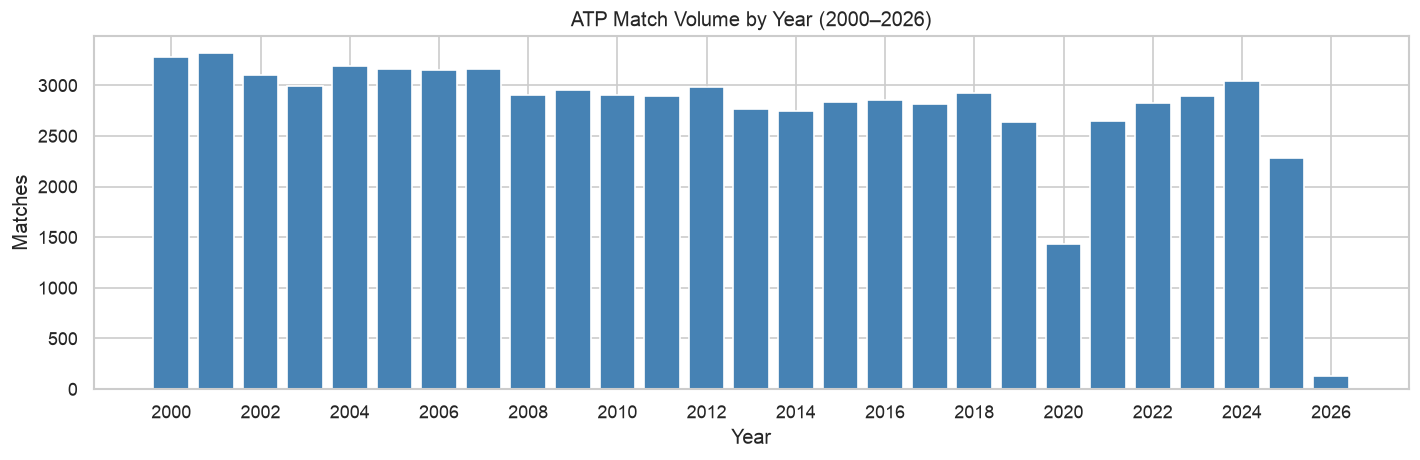

In [3]:
matches_per_year = df.groupby(df['tourney_date'].dt.year).size().reset_index(name='count')
matches_per_year.columns = ['year', 'count']

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(matches_per_year['year'], matches_per_year['count'], color='steelblue', width=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Matches')
ax.set_title('ATP Match Volume by Year (2000–2026)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.tight_layout()
plt.show()

## Surface distribution

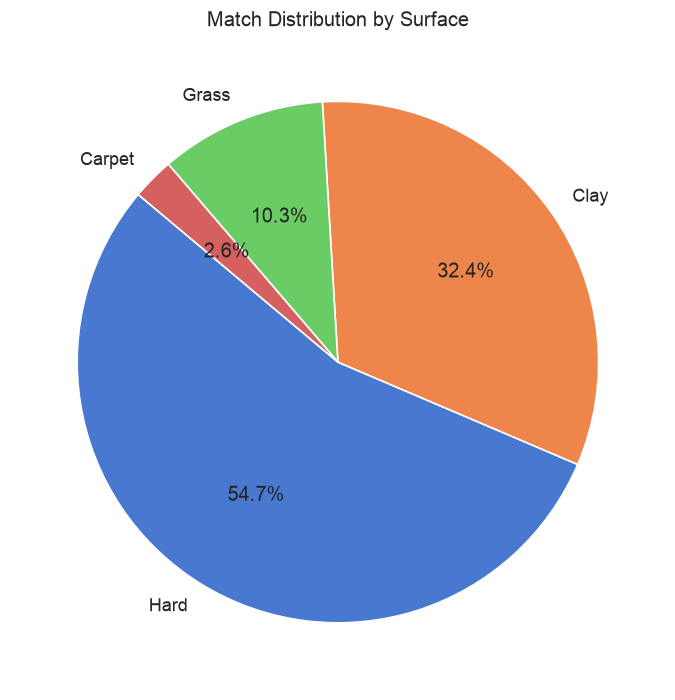

surface
Hard      40862
Clay      24185
Grass      7715
Carpet     1953
Name: count, dtype: int64


In [4]:
surface_counts = df['surface'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    surface_counts.values,
    labels=surface_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('muted', len(surface_counts))
)
ax.set_title('Match Distribution by Surface')
plt.tight_layout()
plt.show()
print(surface_counts)

## Serve statistics coverage

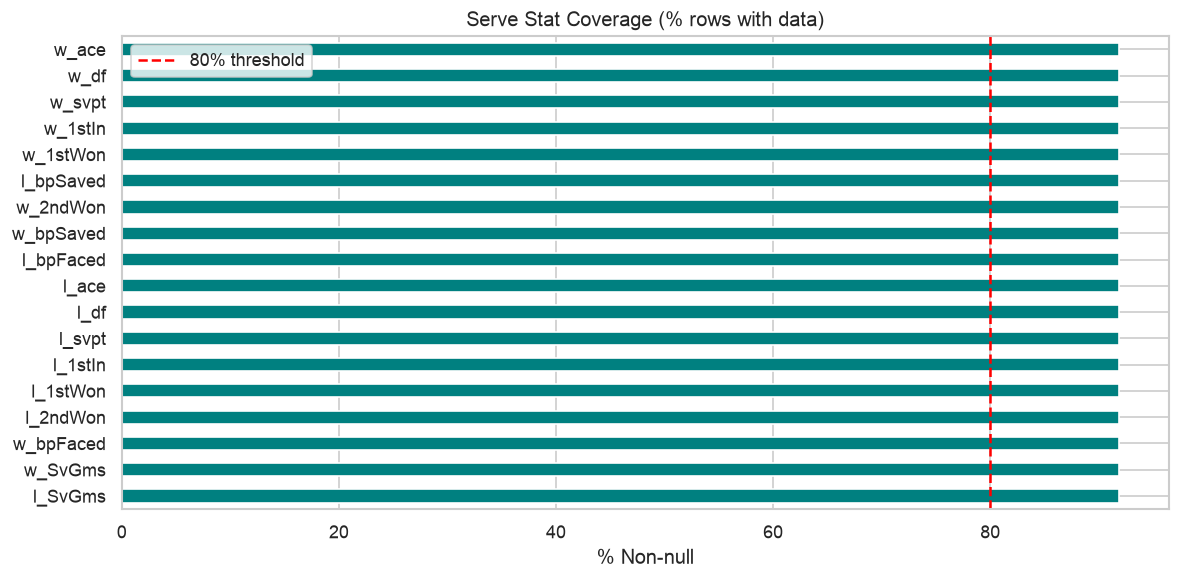

l_SvGms      91.9
w_SvGms      91.9
w_bpFaced    91.9
l_2ndWon     91.9
l_1stWon     91.9
l_1stIn      91.9
l_svpt       91.9
l_df         91.9
l_ace        91.9
l_bpFaced    91.9
w_bpSaved    91.9
w_2ndWon     91.9
l_bpSaved    91.9
w_1stWon     91.9
w_1stIn      91.9
w_svpt       91.9
w_df         91.9
w_ace        91.9
dtype: float64


In [5]:
stat_cols = [
    'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon',
    'w_SvGms', 'w_bpSaved', 'w_bpFaced',
    'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon',
    'l_SvGms', 'l_bpSaved', 'l_bpFaced'
]

coverage = (df[stat_cols].notna().sum() / len(df) * 100).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
coverage.plot.barh(ax=ax, color='teal')
ax.set_xlabel('% Non-null')
ax.set_title('Serve Stat Coverage (% rows with data)')
ax.axvline(80, color='red', linestyle='--', label='80% threshold')
ax.legend()
plt.tight_layout()
plt.show()
print(coverage.round(1))

## Most active players

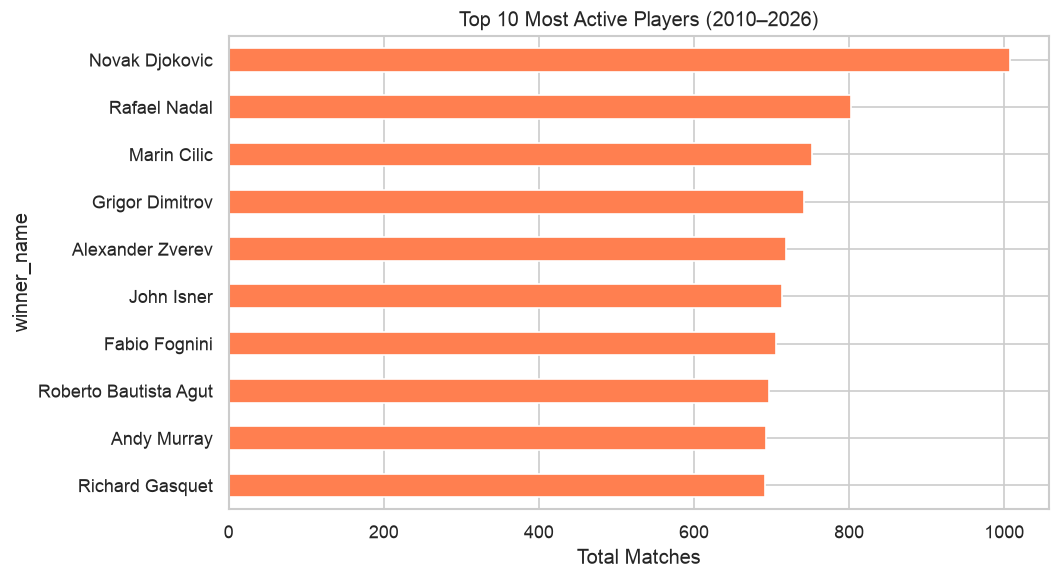

In [6]:
df_2010 = df[df['tourney_date'].dt.year >= 2010]

winner_counts = df_2010['winner_name'].value_counts().rename('wins')
loser_counts = df_2010['loser_name'].value_counts().rename('losses')
match_counts = (winner_counts.add(loser_counts, fill_value=0)).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
match_counts.sort_values().plot.barh(ax=ax, color='coral')
ax.set_xlabel('Total Matches')
ax.set_title('Top 10 Most Active Players (2010–2026)')
plt.tight_layout()
plt.show()

## Surface-level serve stats

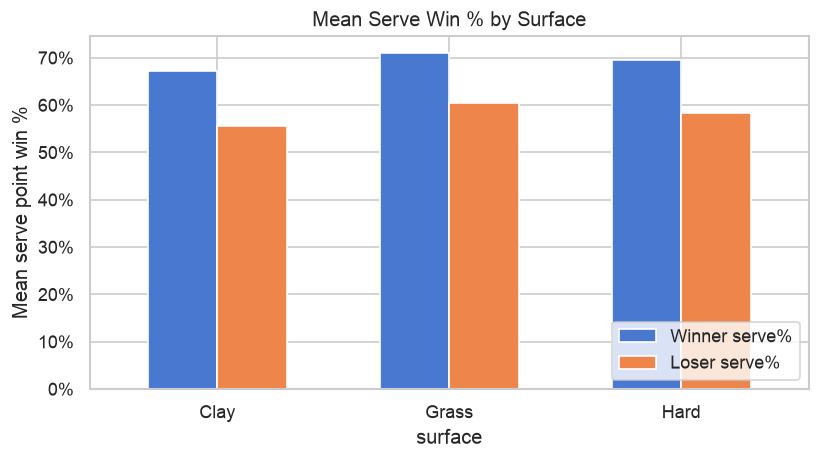

         Winner serve%  Loser serve%
surface                             
Clay            0.6715        0.5560
Grass           0.7100        0.6048
Hard            0.6948        0.5837


In [7]:
surface_serve = (
    df[df['surface'].isin(['Hard', 'Clay', 'Grass'])]
    .groupby('surface')[['w_serve_pct', 'l_serve_pct']]
    .mean()
    .rename(columns={'w_serve_pct': 'Winner serve%', 'l_serve_pct': 'Loser serve%'})
)

fig, ax = plt.subplots(figsize=(7, 4))
surface_serve.plot.bar(ax=ax, rot=0, width=0.6)
ax.set_ylabel('Mean serve point win %')
ax.set_title('Mean Serve Win % by Surface')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
print(surface_serve.round(4))